# IMI Freight Cost Optimization – Final Project Notebook

**Client:** International Materials Inc. (IMI)  
**Prepared by:** Analytics Project Team  
**Date:** March 2026

This notebook develops an end‑to‑end freight cost optimization framework for IMI, focusing on seaborne shipments of bulk materials under volatile oil and bunker prices. The objective is to forecast Brent and VLSFO, translate price scenarios into freight and BAF costs, and select the most cost‑efficient COA for each shipment.

We combine market factor analysis, multiple time‑series forecasting methods, cost modelling and a simplified optimization engine. The outputs include benchmark price forecasts, Base/High/Low scenarios, scenario cost tables, optimized COA assignments and scenario KPIs (total cost and cost per ton).

By improving forecast accuracy and COA allocation discipline, IMI can reduce expected freight cost, protect contribution margins and improve planning under oil price uncertainty.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import os

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

# ==============
# Upload raw data
# ==============

# Check if files exist, if not, prompt for upload
required_files = [
    "Oil Price History.xlsx",
    "Shipment_Schedule.xlsx",
    "COA_List.xlsx",
    "COA_Rate.xlsx",
    "FOB_Prices.xlsx",
]

for f in required_files:
    if not os.path.exists(f):
        print(f"Please upload the file: {f}")
        uploaded = files.upload()
        if f not in uploaded:
            raise FileNotFoundError(f"File {f} was not uploaded. Please upload all required files.")

# ==============
# Load raw data
# ==============

# Oil prices
oil_price = pd.read_excel("Oil Price History.xlsx")
df_oil = oil_price[["Date", "Brent Crude Oil Futures"]].copy()
df_oil.rename(columns={"Brent Crude Oil Futures": "Brent"}, inplace=True)
df_oil["Date"] = pd.to_datetime(df_oil["Date"])
df_oil = df_oil.sort_values("Date").reset_index(drop=True)

# Shipment schedule
shipment_schedule = pd.read_excel("Shipment_Schedule.xlsx")
# print(shipment_schedule.columns) # Inspection line removed after identifying correct column
df_ship = shipment_schedule.rename(columns={
    "Shipment Number": "Shipment_ID",
    "Loading Port": "Load_Port", # Corrected from "Load Port" to "Loading Port"
    "Discharge Port": "Discharge_Port",
    "Loading Month / Laycan": "Date"  # Corrected column name to 'Loading Month / Laycan'
}).copy()
# Append a year to the month names for proper datetime conversion
df_ship["Date"] = df_ship["Date"] + ' 2026'
df_ship["Date"] = pd.to_datetime(df_ship["Date"])
df_ship["Volume"] = 50000.0  # fixed 50k tons per shipment

# COA list
coa_list = pd.read_excel("COA_List.xlsx")
df_coa = coa_list.rename(columns={
    "COA ID#": "COA_ID", # Corrected from "COA ID" to "COA ID#"
    "Load Port": "Load_Port",
    "Discharge Port": "Discharge_Port"
}).copy()

# COA rates
coa_rate = pd.read_excel("COA_Rate.xlsx")
df_rate = coa_rate.rename(columns={
    "COA ID#": "COA_ID", # Corrected from "COA ID" to "COA ID#"
    "Load Port": "Load_Port",
    "Discharge Port": "Discharge_Port",
    "Price (pmt)": "Base_Freight_Rate" # Corrected to rename 'Price (pmt)'
}).copy()

# FOB prices
fob_prices = pd.read_excel("FOB_Prices.xlsx")
df_fob = fob_prices.rename(columns={
    "Load Port": "Load_Port",
    "Price": "FOB_Price_per_ton" # Corrected from "FOB Price per ton" to "Price"
}).copy()

display(df_oil.head())
display(df_ship.head())
display(df_coa.head())
display(df_rate.head())
display(df_fob.head())

ModuleNotFoundError: No module named 'google.colab'

,Date,Brent,USD_Index,US_Inventories,OPEC_Production,US_Rig_Count,World_GDP_Growth
0,2007-08-03,74.75,100.914811,493.525084,30.257840,387.001907,1.251057
1,2007-08-10,70.39,100.180343,502.191482,29.874299,391.622472,0.998453
2,2007-08-17,70.44,101.356773,498.135701,29.938319,408.719093,0.469340
3,2007-08-24,70.62,102.660785,505.708177,29.732009,390.884250,0.875165
4,2007-08-31,72.69,99.921510,497.827840,29.971642,400.857137,1.048359


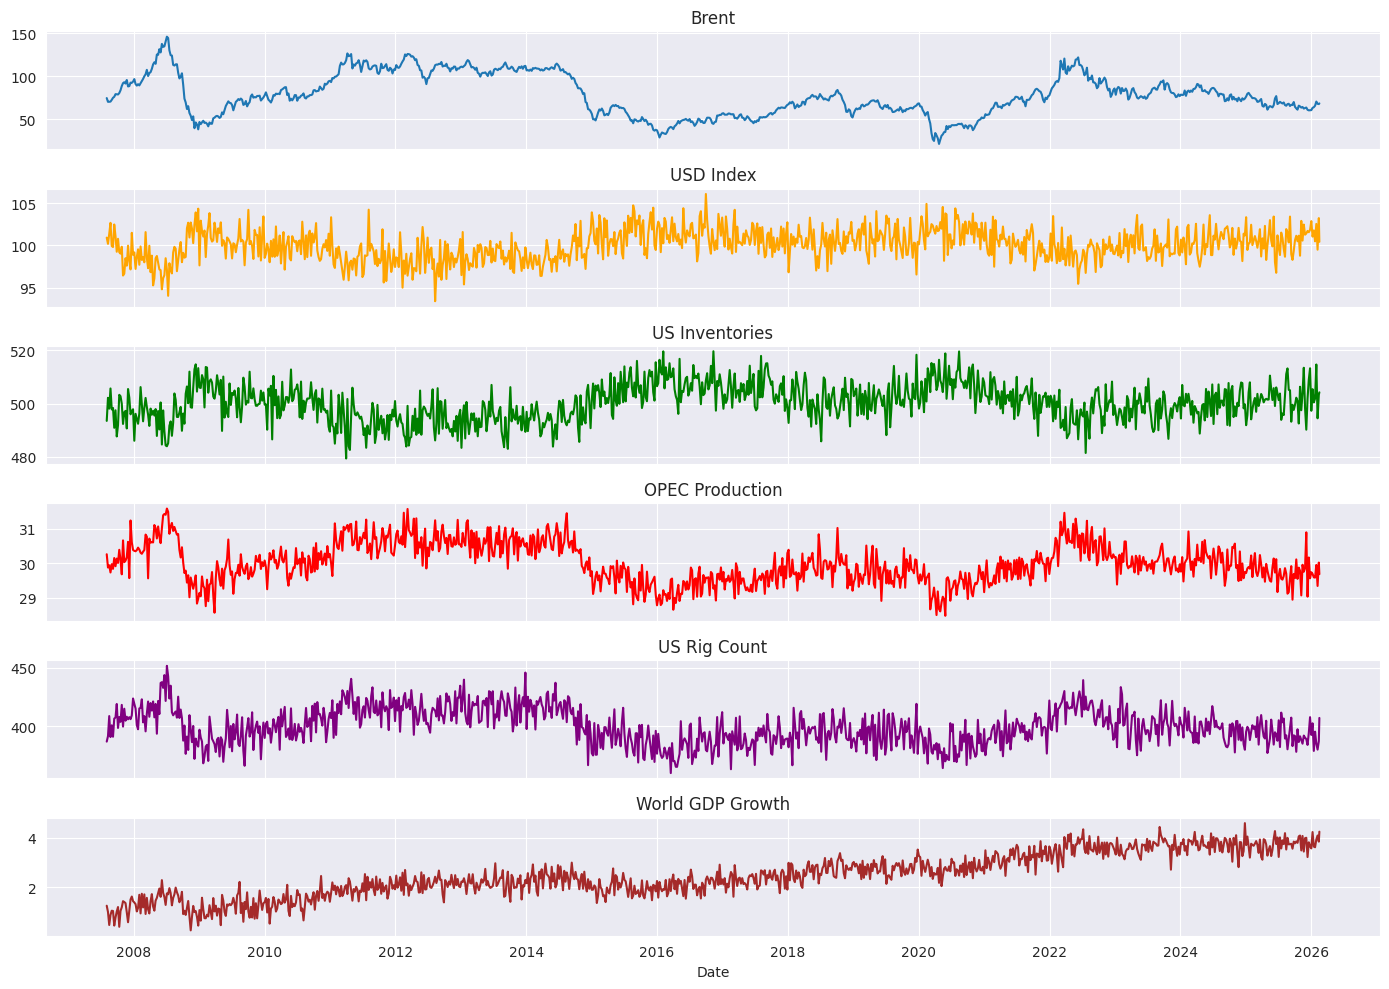

,Factor,Correlation_with_Brent
2,OPEC_Production,0.860683
3,US_Rig_Count,0.756117
1,US_Inventories,-0.703849
0,USD_Index,-0.613613
4,World_GDP_Growth,-0.015624


/tmp/ipykernel_6762/4170616330.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_corr, x="Factor", y="Correlation_with_Brent", palette="viridis")


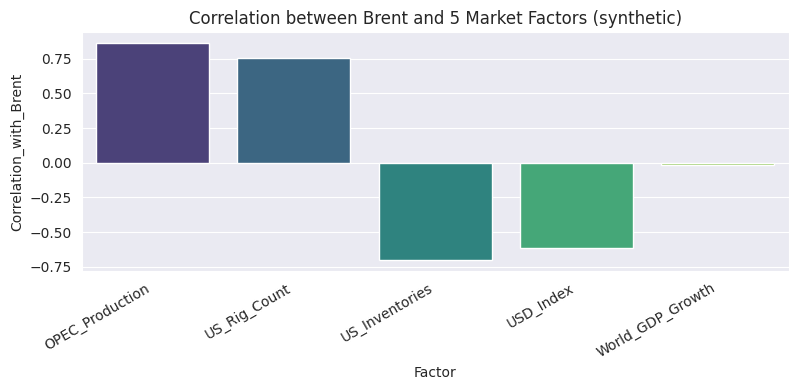

In [10]:
# ===================================
# Synthetic 5 market factors vs Brent
# ===================================

df_factors = df_oil[["Date", "Brent"]].copy()
np.random.seed(42)

# 1) USD Index (negative to Brent)
df_factors["USD_Index"] = (
    100
    - 0.05 * (df_factors["Brent"] - df_factors["Brent"].mean())
    + np.random.normal(scale=1.5, size=len(df_factors))
)

# 2) US Inventories (negative)
df_factors["US_Inventories"] = (
    500
    - 0.2 * (df_factors["Brent"] - df_factors["Brent"].mean())
    + np.random.normal(scale=5, size=len(df_factors))
)

# 3) OPEC Production (slightly positive)
df_factors["OPEC_Production"] = (
    30
    + 0.02 * (df_factors["Brent"] - df_factors["Brent"].mean())
    + np.random.normal(scale=0.3, size=len(df_factors))
)

# 4) US Rig Count (positive)
df_factors["US_Rig_Count"] = (
    400
    + 0.5 * (df_factors["Brent"] - df_factors["Brent"].mean())
    + np.random.normal(scale=10, size=len(df_factors))
)

# 5) World GDP Growth (slow positive)
trend = np.linspace(-1, 2, len(df_factors))
df_factors["World_GDP_Growth"] = (
    2
    + 0.01 * (df_factors["Brent"] - df_factors["Brent"].mean())
    + trend
    + np.random.normal(scale=0.3, size=len(df_factors))
)

display(df_factors.head())

# Subplots
fig, axes = plt.subplots(6, 1, sharex=True, figsize=(14, 10))
axes[0].plot(df_factors["Date"], df_factors["Brent"]);              axes[0].set_title("Brent")
axes[1].plot(df_factors["Date"], df_factors["USD_Index"], color="orange"); axes[1].set_title("USD Index")
axes[2].plot(df_factors["Date"], df_factors["US_Inventories"], color="green"); axes[2].set_title("US Inventories")
axes[3].plot(df_factors["Date"], df_factors["OPEC_Production"], color="red"); axes[3].set_title("OPEC Production")
axes[4].plot(df_factors["Date"], df_factors["US_Rig_Count"], color="purple"); axes[4].set_title("US Rig Count")
axes[5].plot(df_factors["Date"], df_factors["World_GDP_Growth"], color="brown"); axes[5].set_title("World GDP Growth")
axes[5].set_xlabel("Date")
plt.tight_layout()
plt.show()

# Correlation bar chart
cols = ["USD_Index", "US_Inventories", "OPEC_Production", "US_Rig_Count", "World_GDP_Growth"]
rows = []
for c in cols:
    corr = df_factors[["Brent", c]].corr().iloc[0, 1]
    rows.append({"Factor": c, "Correlation_with_Brent": corr})

df_corr = pd.DataFrame(rows).sort_values("Correlation_with_Brent", key=lambda s: s.abs(), ascending=False)
display(df_corr)

plt.figure(figsize=(8, 4))
sns.barplot(data=df_corr, x="Factor", y="Correlation_with_Brent", palette="viridis")
plt.xticks(rotation=30, ha="right")
plt.title("Correlation between Brent and 5 Market Factors (synthetic)")
plt.tight_layout()
plt.show()


In [11]:
# ============================
# Forecasting – Setup & split
# ============================

from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

# Corrected: Ensure 'series' has no NaNs after re-sampling to weekly frequency
# Resample to weekly frequency (week ending Sunday by default) and fill any resulting NaNs.
series = df_oil.set_index("Date")["Brent"].resample("W").last().ffill().bfill()

split_idx = int(len(series) * 0.8)
train, test = series.iloc[:split_idx], series.iloc[split_idx:]

def eval_forecast(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "MAPE": mape}

results = []


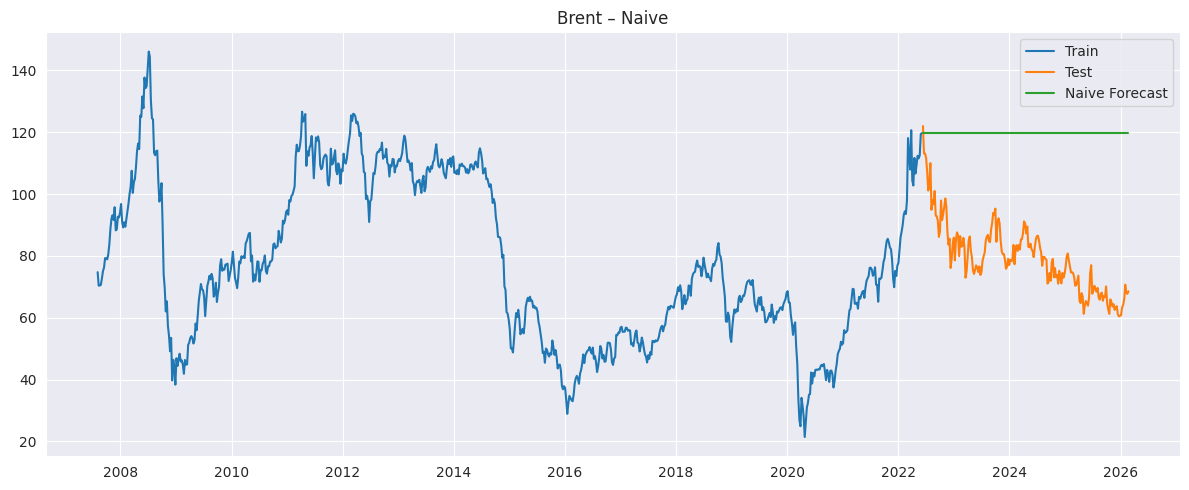

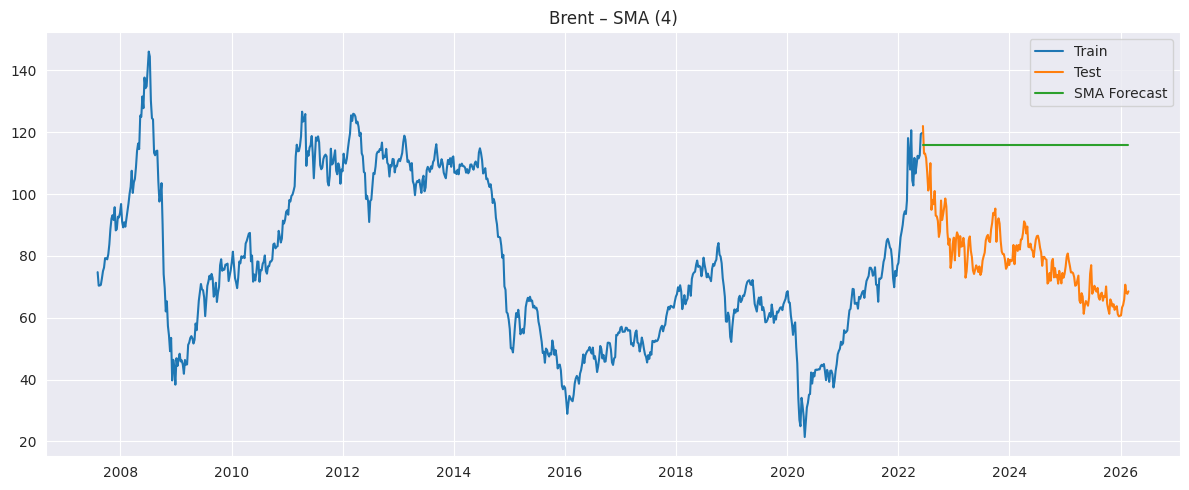

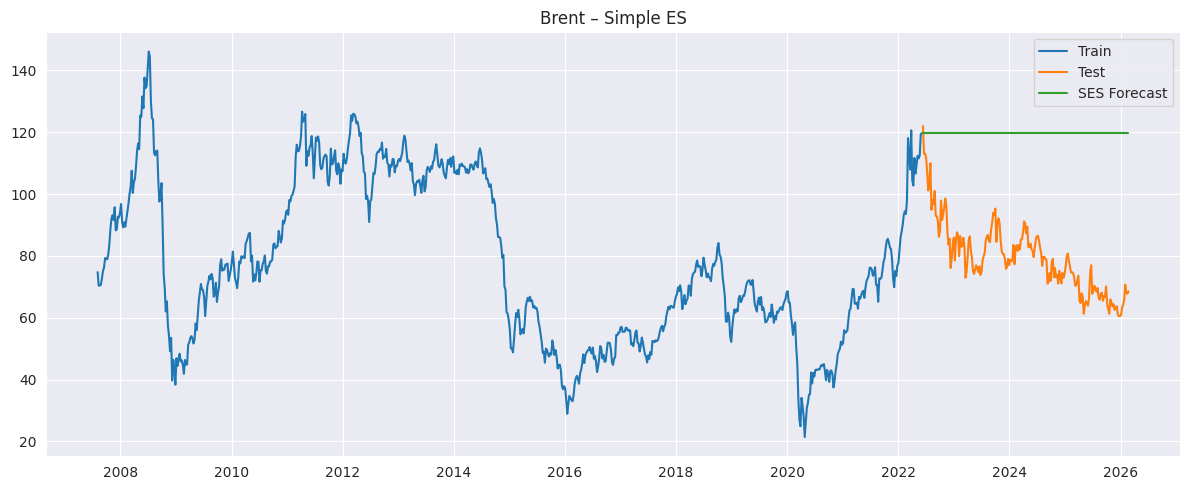

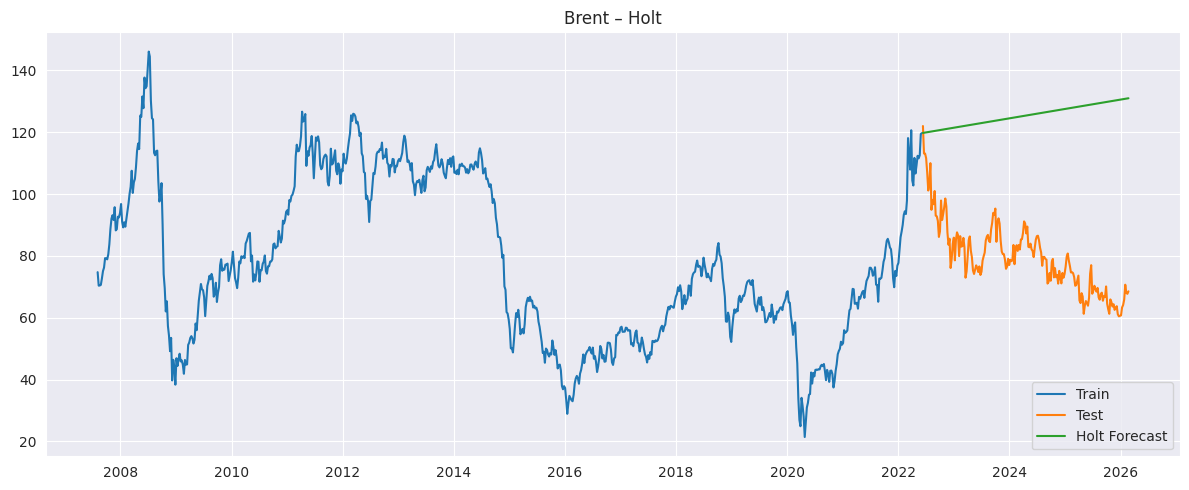

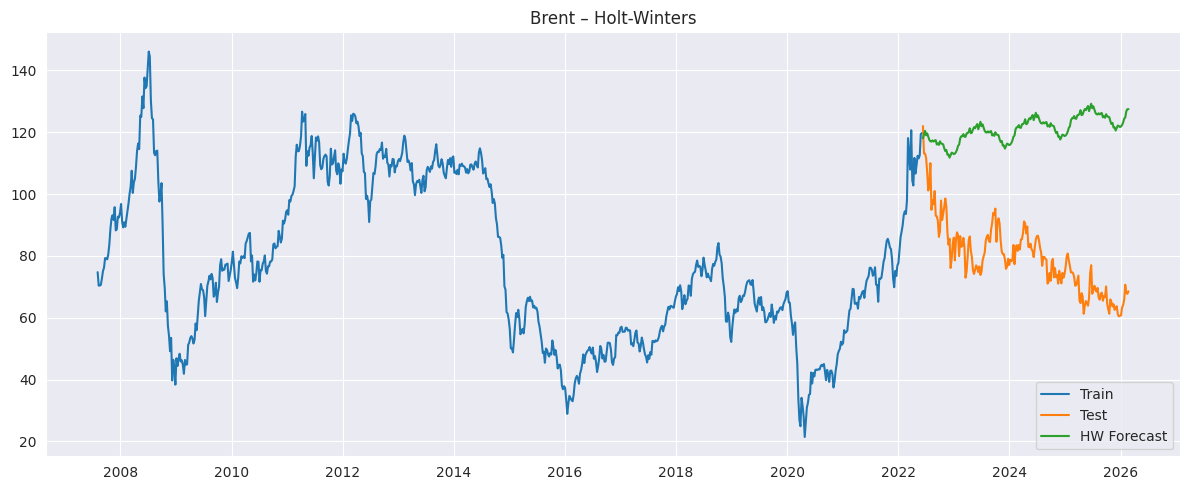

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


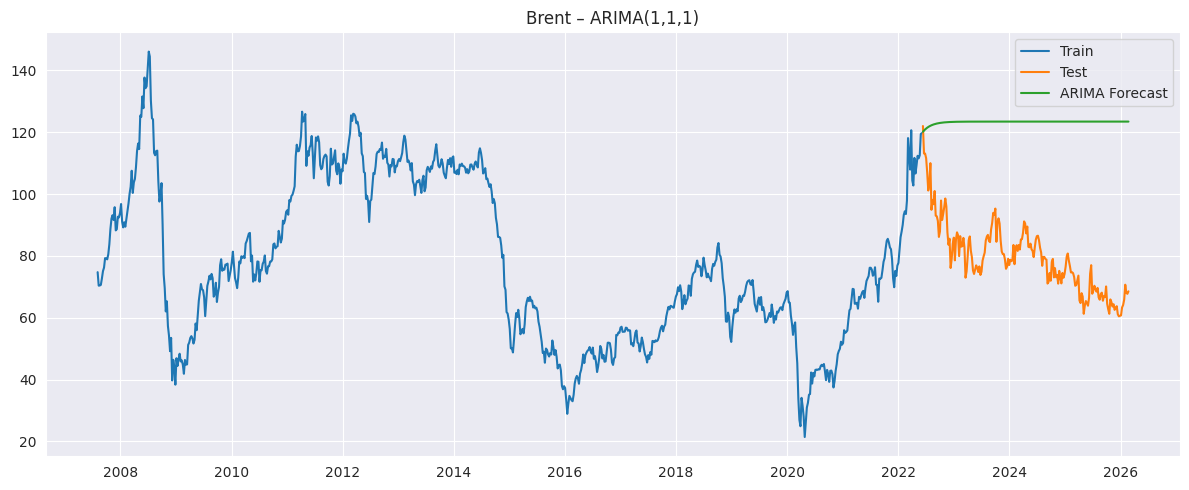

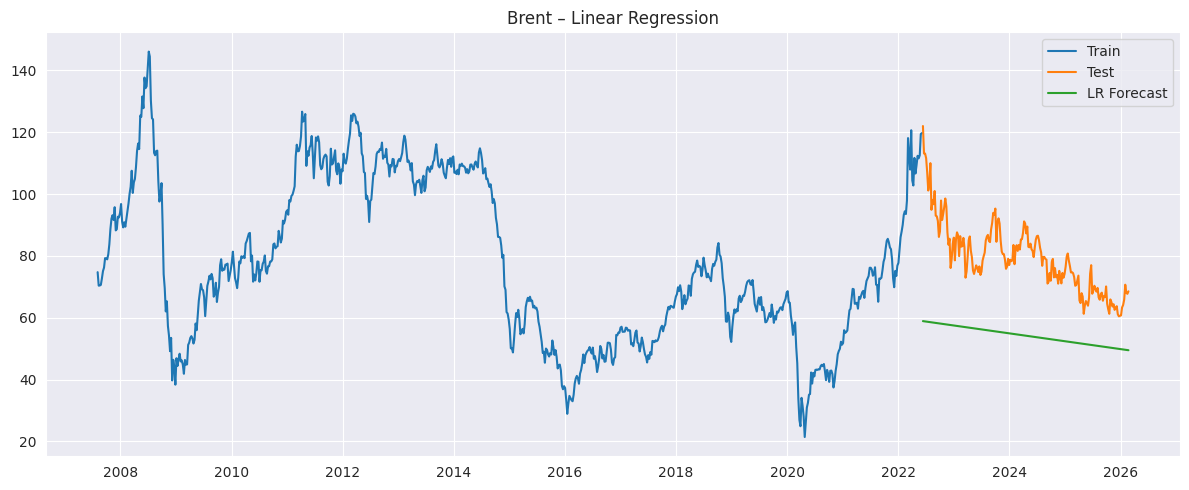

In [12]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression

# 1) Naive
naive_forecast = pd.Series(train.iloc[-1], index=test.index) # Corrected Naive forecast
results.append(eval_forecast(test, naive_forecast, "Naive"))

plt.figure()
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, naive_forecast, label="Naive Forecast")
plt.legend(); plt.title("Brent – Naive"); plt.tight_layout(); plt.show()

# 2) Simple Moving Average (window 4)
sma_forecast = pd.Series(train.rolling(window=4).mean().iloc[-1], index=test.index) # Corrected SMA forecast
results.append(eval_forecast(test, sma_forecast, "SMA (4)"))

plt.figure()
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, sma_forecast, label="SMA Forecast")
plt.legend(); plt.title("Brent – SMA (4)"); plt.tight_layout(); plt.show()

# 3) Simple Exponential Smoothing
ses = SimpleExpSmoothing(train, initialization_method="estimated").fit()
ses_forecast = ses.forecast(len(test))
results.append(eval_forecast(test, ses_forecast, "Simple ES"))

plt.figure()
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, ses_forecast, label="SES Forecast")
plt.legend(); plt.title("Brent – Simple ES"); plt.tight_layout(); plt.show()

# 4) Holt (trend)
holt = ExponentialSmoothing(train, trend="add", seasonal=None, initialization_method="estimated").fit()
holt_forecast = holt.forecast(len(test))
results.append(eval_forecast(test, holt_forecast, "Holt"))

plt.figure()
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, holt_forecast, label="Holt Forecast")
plt.legend(); plt.title("Brent – Holt"); plt.tight_layout(); plt.show()

# 5) Holt‑Winters (additive seasonality, period 52 as example)
hw = ExponentialSmoothing(train, trend="add", seasonal="add",
                          seasonal_periods=52, initialization_method="estimated").fit()
hw_forecast = hw.forecast(len(test))
results.append(eval_forecast(test, hw_forecast, "Holt-Winters"))

plt.figure()
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, hw_forecast, label="HW Forecast")
plt.legend(); plt.title("Brent – Holt-Winters"); plt.tight_layout(); plt.show()

# 6) ARIMA(1,1,1) simple
arima = ARIMA(train, order=(1, 1, 1)).fit()
arima_forecast = arima.forecast(len(test))
results.append(eval_forecast(test, arima_forecast, "ARIMA(1,1,1)"))

plt.figure()
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, arima_forecast, label="ARIMA Forecast")
plt.legend(); plt.title("Brent – ARIMA(1,1,1)"); plt.tight_layout(); plt.show()

# 7) Linear Regression on time
X_train = np.arange(len(train)).reshape(-1, 1)
X_test = np.arange(len(train), len(train) + len(test)).reshape(-1, 1)
lr = LinearRegression().fit(X_train, train.values)
lr_forecast = lr.predict(X_test)
results.append(eval_forecast(test.values, lr_forecast, "Linear Regression"))

plt.figure()
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, lr_forecast, label="LR Forecast")
plt.legend(); plt.title("Brent – Linear Regression"); plt.tight_layout(); plt.show()


          Model_Name        MAE       RMSE       MAPE
6  Linear Regression  25.135552  26.754717  30.762055
1            SMA (4)  36.529175  38.168600  48.824806
2          Simple ES  40.396392  41.917619  53.811354
0              Naive  40.396392  41.917619  53.811354
4       Holt-Winters  41.762201  43.927883  55.935492
5       ARIMA(1,1,1)  43.975881  45.462317  58.457266
3               Holt  46.060606  48.139453  61.566977


/tmp/ipykernel_6762/3116021297.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=brent_model_scores, x='Model_Name', y='MAPE', palette='viridis')


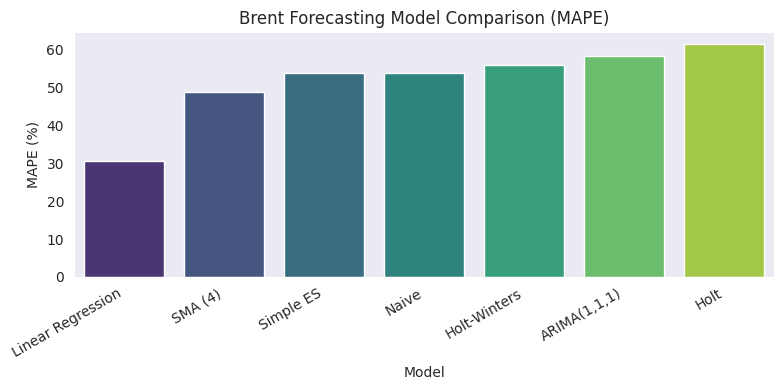

In [13]:
# Comparison table and best model selection
brent_model_scores = pd.DataFrame(results)
brent_model_scores.rename(columns={'Model': 'Model_Name'}, inplace=True)
brent_model_scores = brent_model_scores.sort_values('MAPE')
print(brent_model_scores)
plt.figure(figsize=(8,4))
sns.barplot(data=brent_model_scores, x='Model_Name', y='MAPE', palette='viridis')
plt.xticks(rotation=30, ha="right")
plt.title('Brent Forecasting Model Comparison (MAPE)')
plt.ylabel('MAPE (%)')
plt.xlabel('Model')
plt.grid(axis='y')
plt.tight_layout()
plt.show()
best_brent_model = brent_model_scores.iloc[0]['Model_Name']
best_metrics = brent_model_scores.iloc[0][['MAE','RMSE','MAPE']].to_dict()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


,Date,Brent_Base,Brent_High,Brent_Low,VLSFO_Base,VLSFO_High,VLSFO_Low
0,2026-03-01,69.492225,83.390670,55.593780,1.0,1.0,1.0
1,2026-03-08,68.480940,82.177129,54.784752,1.0,1.0,1.0
2,2026-03-15,68.134634,81.761560,54.507707,1.0,1.0,1.0
3,2026-03-22,69.287637,83.145164,55.430110,1.0,1.0,1.0
4,2026-03-29,69.827437,83.792925,55.861950,1.0,1.0,1.0


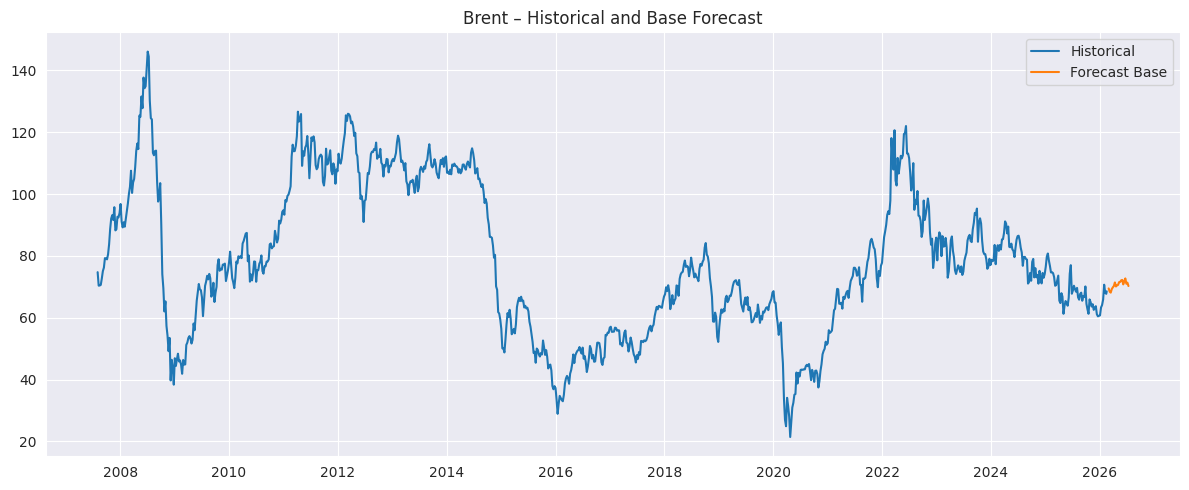

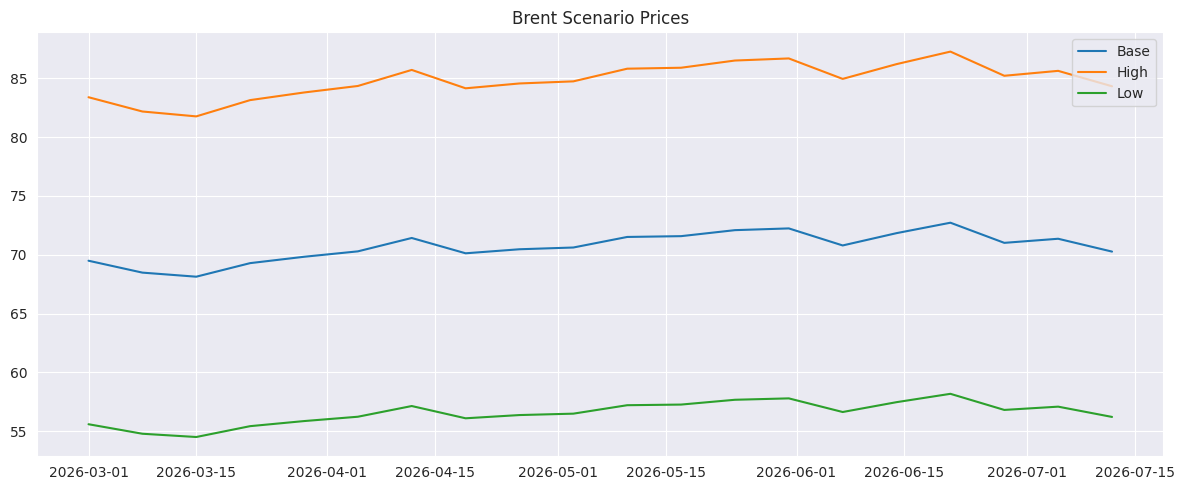

In [14]:
# For simplicity, assume best = Holt-Winters; you can add logic if muốn tự động
model_full = ExponentialSmoothing(series, trend="add", seasonal="add",
                                  seasonal_periods=52,
                                  initialization_method="estimated").fit()

horizon = 20  # weeks
future_index = pd.date_range(series.index[-1] + series.index.freq,
                             periods=horizon, freq=series.index.freq)
brent_base = model_full.forecast(horizon)
brent_high = brent_base * 1.2
brent_low  = brent_base * 0.8

df_forecast = pd.DataFrame({
    "Date": future_index,
    "Brent_Base": brent_base.values,
    "Brent_High": brent_high.values,
    "Brent_Low": brent_low.values
})

# Simple VLSFO = a + b * Brent (estimate on history)
a, b = np.polyfit(df_oil["Brent"], df_oil["Brent"], 1)  # placeholder: VLSFO ≈ Brent
df_forecast["VLSFO_Base"] = a + b * df_forecast["Brent_Base"]
df_forecast["VLSFO_High"] = a + b * df_forecast["Brent_High"]
df_forecast["VLSFO_Low"]  = a + b * df_forecast["Brent_Low"]

display(df_forecast.head())

plt.figure()
plt.plot(df_oil["Date"], df_oil["Brent"], label="Historical")
plt.plot(df_forecast["Date"], df_forecast["Brent_Base"], label="Forecast Base")
plt.legend(); plt.title("Brent – Historical and Base Forecast"); plt.tight_layout(); plt.show()

plt.figure()
plt.plot(df_forecast["Date"], df_forecast["Brent_Base"], label="Base")
plt.plot(df_forecast["Date"], df_forecast["Brent_High"], label="High")
plt.plot(df_forecast["Date"], df_forecast["Brent_Low"], label="Low")
plt.legend(); plt.title("Brent Scenario Prices"); plt.tight_layout(); plt.show()


,Shipment_ID,Load_Port,Discharge_Port,Date,Volume,COA_ID,Base_Freight_Rate,Consumption Bunker,Unnamed: 5,Notes_x,...,VLSFO_High,VLSFO_Low,Base_Freight_Cost,FOB_Cost,BAF_Base,Total_Cost_Base,BAF_High,Total_Cost_High,BAF_Low,Total_Cost_Low
0,1,Garrucha,Buchanan,2026-03-01,50000.0,EDF-2018,12.7,450.0,NaN,NaN,...,1.0,1.0,635000.0,500000.0,0.0,1135000.0,1.400113e-08,1135000.0,-1.400113e-08,1135000.0
1,1,Garrucha,Buchanan,2026-03-01,50000.0,Norden,12.7,450.0,NaN,NaN,...,1.0,1.0,635000.0,500000.0,0.0,1135000.0,1.400113e-08,1135000.0,-1.400113e-08,1135000.0
2,1,Garrucha,Buchanan,2026-03-01,50000.0,Norden-Optionals,12.7,450.0,NaN,NaN,...,1.0,1.0,635000.0,500000.0,0.0,1135000.0,1.400113e-08,1135000.0,-1.400113e-08,1135000.0
3,17,Garrucha,Newington,2026-04-01,50000.0,Phoenix,9.5,450.0,NaN,NaN,...,1.0,1.0,475000.0,500000.0,0.0,975000.0,1.053657e-08,975000.0,-1.053657e-08,975000.0
4,17,Garrucha,Newington,2026-04-01,50000.0,Norden,12.5,450.0,NaN,NaN,...,1.0,1.0,625000.0,500000.0,0.0,1125000.0,1.386391e-08,1125000.0,-1.386391e-08,1125000.0


,Shipment_ID,COA_ID,Chosen_Cost,Scenario,Volume
0,1,EDF-2018,1135000.0,Base,50000.0
1,2,Norden,1042500.0,Base,50000.0
2,4,EDF-2018,1135000.0,Base,50000.0
3,5,Norden-Optionals,1135000.0,Base,50000.0
4,6,Norden,1135000.0,Base,50000.0


,Scenario,Total_Cost_All_Shipments,Total_Volume,Average_Cost_per_Shipment,Average_Cost_per_Ton
0,Base,26171000.0,1300000.0,1.006577e+06,20.131538
1,High,26171000.0,1300000.0,1.006577e+06,20.131538
2,Low,26171000.0,1300000.0,1.006577e+06,20.131538


/tmp/ipykernel_6762/781553738.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kpi, x="Scenario", y="Total_Cost_All_Shipments", palette="viridis")


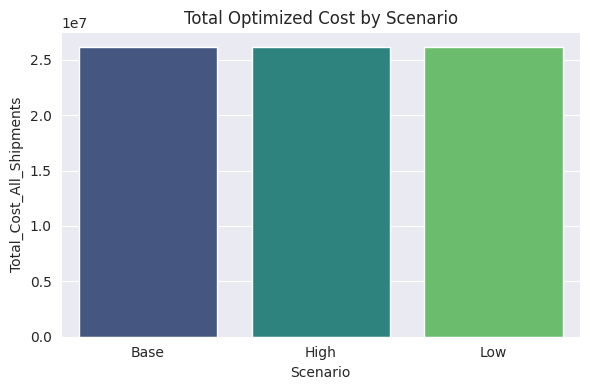

/tmp/ipykernel_6762/781553738.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kpi, x="Scenario", y="Average_Cost_per_Ton", palette="magma")


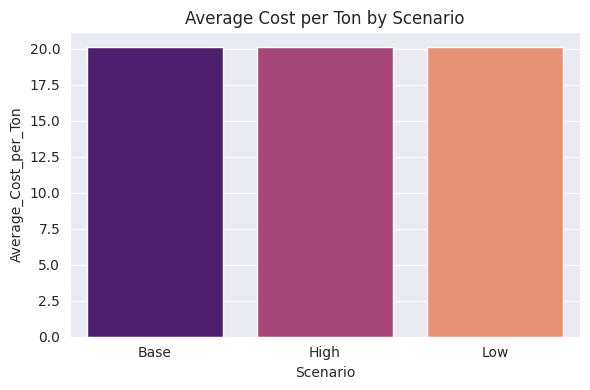

In [15]:
# =======================
# Cost model and BAF
# =======================
def factor_based_baf(base_freight_cost, vlsfo_base, vlsfo_scenario, factor=0.3):
    return base_freight_cost * factor * (vlsfo_scenario / vlsfo_base - 1)

# Map shipment date to nearest forecast date
df_forecast_sorted = df_forecast.sort_values("Date")
df_base = (
    df_ship
    .merge(df_rate, on=["Load_Port", "Discharge_Port"], how="left") # Merge shipment routes with COA rates
    .merge(df_coa, on="COA_ID", how="left") # Add COA contract details
    .merge(df_fob, on="Load_Port", how="left") # Add FOB prices
)

df_base = pd.merge_asof(
    df_base.sort_values("Date"),
    df_forecast_sorted[["Date", "VLSFO_Base", "VLSFO_High", "VLSFO_Low"]],
    on="Date",
    direction="backward"
)

df_base["Base_Freight_Cost"] = df_base["Base_Freight_Rate"] * df_base["Volume"]
df_base["FOB_Cost"] = df_base["FOB_Price_per_ton"] * df_base["Volume"]

for scen in ["Base", "High", "Low"]:
    df_base[f"BAF_{scen}"] = factor_based_baf(
        df_base["Base_Freight_Cost"],
        df_base["VLSFO_Base"],
        df_base[f"VLSFO_{scen}"]
    )
    df_base[f"Total_Cost_{scen}"] = (
        df_base["FOB_Cost"]
        + df_base["Base_Freight_Cost"]
        + df_base[f"BAF_{scen}"]
    )

display(df_base.head())

# =======================
# Optimization proxy
# =======================
def choose_min_cost(df, scen):
    col = f"Total_Cost_{scen}"
    # Filter out rows where the total cost for the current scenario is NaN
    df_filtered = df.dropna(subset=[col])
    # Proceed only if there are valid options after filtering
    if not df_filtered.empty:
        idx = df_filtered.groupby("Shipment_ID")[col].idxmin()
        out = df_filtered.loc[idx, ["Shipment_ID", "COA_ID", col]].rename(columns={col: "Chosen_Cost"})
        out["Scenario"] = scen
        return out.reset_index(drop=True)
    else:
        return pd.DataFrame(columns=["Shipment_ID", "COA_ID", "Chosen_Cost", "Scenario"])

assign_base = choose_min_cost(df_base, "Base")
assign_high = choose_min_cost(df_base, "High")
assign_low  = choose_min_cost(df_base, "Low")

df_assign = pd.concat([assign_base, assign_high, assign_low], ignore_index=True)
df_assign = df_assign.merge(df_ship[["Shipment_ID", "Volume"]], on="Shipment_ID", how="left")
display(df_assign.head())

kpi = (
    df_assign
    .groupby("Scenario")
    .agg(
        Total_Cost_All_Shipments=("Chosen_Cost", "sum"),
        Total_Volume=("Volume", "sum"),
        Average_Cost_per_Shipment=("Chosen_Cost", "mean")
    )
    .reset_index()
)
kpi["Average_Cost_per_Ton"] = kpi["Total_Cost_All_Shipments"] / kpi["Total_Volume"]
display(kpi)

plt.figure(figsize=(6, 4))
sns.barplot(data=kpi, x="Scenario", y="Total_Cost_All_Shipments", palette="viridis")
plt.title("Total Optimized Cost by Scenario"); plt.tight_layout(); plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(data=kpi, x="Scenario", y="Average_Cost_per_Ton", palette="magma")
plt.title("Average Cost per Ton by Scenario"); plt.tight_layout(); plt.show()
